In [2]:
df = pd.read_csv("../data/cleaned/final_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (98053, 65)


,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,doctor_id,admission_date,bed_occupancy,patient_satisfaction,length_of_stay,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,department_Endocrinology,department_General Medicine,department_Neurology,department_Surgery,"location_Houston, TX","location_Los Angeles, CA","location_New York, NY","location_Phoenix, AZ",readmitted_>30,readmitted_NO,diabetesMed_Yes,change_No
0,149190,55629189,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,DOC_8270,2007-10-03,90,2,3,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False
1,64410,86047875,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,DOC_1860,2005-11-13,82,1,2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,True
2,500364,82442376,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,DOC_6390,2002-04-11,59,4,2,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False
3,16680,42519267,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,DOC_6191,2003-06-26,85,5,1,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False
4,35754,82637451,[50-60),2,1,2,3,31,6,16,0,0,0,414,411,250,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,DOC_6734,2002-08-19,94,5,3,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,True,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98053 entries, 0 to 98052
Data columns (total 65 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   encounter_id                 98053 non-null  int64
 1   patient_nbr                  98053 non-null  int64
 2   age                          98053 non-null  str  
 3   admission_type_id            98053 non-null  int64
 4   discharge_disposition_id     98053 non-null  int64
 5   admission_source_id          98053 non-null  int64
 6   time_in_hospital             98053 non-null  int64
 7   num_lab_procedures           98053 non-null  int64
 8   num_procedures               98053 non-null  int64
 9   num_medications              98053 non-null  int64
 10  number_outpatient            98053 non-null  int64
 11  number_emergency             98053 non-null  int64
 12  number_inpatient             98053 non-null  int64
 13  diag_1                       98053 non-null  str  
 14  d

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option('display.max_columns', None)

In [4]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'doctor_id',
 'admission_date',
 'bed_occupancy',
 'patient_satisfaction',
 'length_of_stay',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Other',
 'gender_Male',
 'gender_Unknown/Invalid',
 'department_Endocrinology',
 'departm

In [5]:
df.isnull().sum().sort_values(ascending=False)

max_glu_serum           92845
A1Cresult               81860
encounter_id                0
patient_nbr                 0
age                         0
                        ...  
location_Phoenix, AZ        0
readmitted_>30              0
readmitted_NO               0
diabetesMed_Yes             0
change_No                   0
Length: 65, dtype: int64

In [6]:
df_clean = df.copy()

df_clean.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "max_glu_serum",
        "A1Cresult"
    ],
    inplace=True
)

print(df_clean.shape)

(98053, 61)


In [7]:
df_clean["age"].unique()

<ArrowStringArray>
[ '[10-20)',  '[20-30)',  '[30-40)',  '[40-50)',  '[50-60)',  '[60-70)',
  '[70-80)',  '[80-90)', '[90-100)',   '[0-10)']
Length: 10, dtype: str

In [8]:
age_mapping = {
    '[0-10)': 5,
    '[10-20)': 15,
    '[20-30)': 25,
    '[30-40)': 35,
    '[40-50)': 45,
    '[50-60)': 55,
    '[60-70)': 65,
    '[70-80)': 75,
    '[80-90)': 85,
    '[90-100)': 95
}

df_clean["age"] = df_clean["age"].map(age_mapping)

In [9]:
df_clean["age"].head()

0    15
1    25
2    35
3    45
4    55
Name: age, dtype: int64

In [10]:
df_clean.select_dtypes(include="object").columns.tolist()

C:\Users\abc\AppData\Local\Temp\ipykernel_1728\2435950628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.select_dtypes(include="object").columns.tolist()


['diag_1',
 'diag_2',
 'diag_3',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'doctor_id',
 'admission_date']

In [11]:
df_clean.drop(
    columns=[
        "doctor_id",
        "admission_date"
    ],
    inplace=True
)

In [12]:
df_clean["metformin"].value_counts()

metformin
No        78808
Steady    17677
Up         1017
Down        551
Name: count, dtype: int64

In [13]:
df_clean["insulin"].value_counts()

insulin
No        45943
Steady    29368
Down      11843
Up        10899
Name: count, dtype: int64

In [14]:
df_clean["diag_1"].head()

0    276
1    648
2      8
3    197
4    414
Name: diag_1, dtype: str

In [15]:
df_clean["diag_1"].nunique()

713

In [16]:
df_clean["diag_2"].nunique()

740

In [19]:
df_clean.drop(
    columns=[
        "diag_1",
        "diag_2",
        "diag_3"
    ],
    inplace=True
)


In [20]:
df_clean.select_dtypes(include="object").columns.tolist()

C:\Users\abc\AppData\Local\Temp\ipykernel_1728\2435950628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_clean.select_dtypes(include="object").columns.tolist()


['metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone']

In [21]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df_clean[col].unique())

C:\Users\abc\AppData\Local\Temp\ipykernel_1728\128185958.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:



metformin
<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

repaglinide
<ArrowStringArray>
['No', 'Up', 'Steady', 'Down']
Length: 4, dtype: str

nateglinide
<ArrowStringArray>
['No', 'Steady', 'Down', 'Up']
Length: 4, dtype: str

chlorpropamide
<ArrowStringArray>
['No', 'Steady', 'Down', 'Up']
Length: 4, dtype: str

glimepiride
<ArrowStringArray>
['No', 'Steady', 'Down', 'Up']
Length: 4, dtype: str

acetohexamide
<ArrowStringArray>
['No', 'Steady']
Length: 2, dtype: str

glipizide
<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

glyburide
<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

tolbutamide
<ArrowStringArray>
['No', 'Steady']
Length: 2, dtype: str

pioglitazone
<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

rosiglitazone
<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

acarbose
<ArrowStringArray>
['No', 'Steady', 'Up', 'Down']
Length: 4, dtype: str

miglitol

In [22]:
medication_mapping = {
    "No": 0,
    "Steady": 1,
    "Up": 2,
    "Down": 3
}

In [23]:
medication_columns = df_clean.select_dtypes(include="object").columns

for col in medication_columns:
    df_clean[col] = df_clean[col].map(medication_mapping)

C:\Users\abc\AppData\Local\Temp\ipykernel_1728\3803611823.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  medication_columns = df_clean.select_dtypes(include="object").columns


In [24]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 98053 entries, 0 to 98052
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   age                          98053 non-null  int64
 1   admission_type_id            98053 non-null  int64
 2   discharge_disposition_id     98053 non-null  int64
 3   admission_source_id          98053 non-null  int64
 4   time_in_hospital             98053 non-null  int64
 5   num_lab_procedures           98053 non-null  int64
 6   num_procedures               98053 non-null  int64
 7   num_medications              98053 non-null  int64
 8   number_outpatient            98053 non-null  int64
 9   number_emergency             98053 non-null  int64
 10  number_inpatient             98053 non-null  int64
 11  number_diagnoses             98053 non-null  int64
 12  metformin                    98053 non-null  int64
 13  repaglinide                  98053 non-null  int64
 14  n

In [25]:
df_clean.select_dtypes(include="object").columns.tolist()

[]

In [26]:
bool_cols = df_clean.select_dtypes(include="bool").columns

df_clean[bool_cols] = df_clean[bool_cols].astype(int)


In [27]:
df_clean.dtypes.value_counts()

int64    56
Name: count, dtype: int64

# Feature Scaling

Feature scaling is applied to standardize all features. This ensures that variables with larger numerical ranges do not dominate the clustering process.

In [29]:
X = df_clean.copy()

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (98053, 56)


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (98053, 56)


In [31]:
X_scaled[:5]

array([[-3.28788532e+00, -7.07403356e-01, -5.18587105e-01,
         3.00447527e-01, -4.75091127e-01,  8.04179249e-01,
        -7.90606569e-01,  2.31900548e-01, -2.93277151e-01,
        -2.14725445e-01, -5.08935736e-01,  8.11978370e-01,
        -4.59468824e-01, -1.17810869e-01, -8.09783153e-02,
        -2.78462048e-02, -2.15255768e-01, -3.19353567e-03,
        -3.47482582e-01, -3.11719881e-01, -1.49806143e-02,
        -2.67799217e-01, -2.49696018e-01, -5.36186843e-02,
        -1.73341288e-02, -5.53142245e-03, -1.91912437e-02,
         0.00000000e+00,  0.00000000e+00,  1.08924696e+00,
        -8.18335132e-02, -1.15151613e-02, -3.19353567e-03,
         0.00000000e+00, -3.19353567e-03,  1.07566916e+00,
        -7.10392938e-01, -4.75091127e-01, -8.00936554e-02,
         5.53170573e-01, -1.43707422e-01, -1.23964714e-01,
        -9.25132059e-01, -3.19353567e-03, -5.03509709e-01,
         2.00592166e+00, -4.99066019e-01, -4.99958568e-01,
        -4.98779059e-01, -5.00197589e-01,  2.00669187e+0

In [32]:
inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

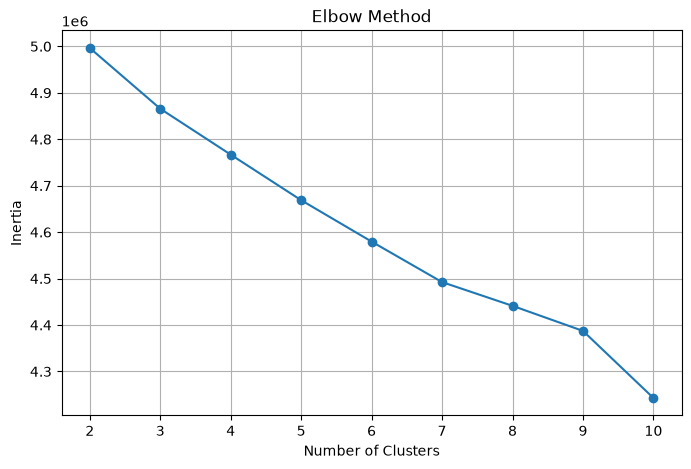

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [34]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [35]:
df_clean["Cluster"] = clusters

In [36]:
df_clean["Cluster"].head()


0    2
1    3
2    2
3    2
4    3
Name: Cluster, dtype: int32

In [37]:
df_clean["Cluster"].value_counts()

Cluster
3    43648
2    33154
1    19266
0     1984
4        1
Name: count, dtype: int64

In [38]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.05924987649941598


In [39]:
from sklearn.cluster import KMeans

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_4 = kmeans_4.fit_predict(X_scaled)

In [40]:
df_clean["Cluster"] = clusters_4

In [41]:
df_clean["Cluster"].value_counts()

Cluster
3    43648
2    33155
1    19266
0     1984
Name: count, dtype: int64

In [42]:
from sklearn.metrics import silhouette_score

score_4 = silhouette_score(
    X_scaled,
    clusters_4
)

print("Silhouette Score (K=4):", score_4)

Silhouette Score (K=4): 0.05921758499219315


In [43]:
cluster_profiles = df_clean.groupby("Cluster").mean()

cluster_profiles

,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,bed_occupancy,patient_satisfaction,length_of_stay,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,department_Endocrinology,department_General Medicine,department_Neurology,department_Surgery,"location_Houston, TX","location_Los Angeles, CA","location_New York, NY","location_Phoenix, AZ",readmitted_>30,readmitted_NO,diabetesMed_Yes,change_No
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,59.228831,2.318548,3.351310,6.150202,4.104839,42.875000,1.129536,14.182460,0.332661,0.232359,0.621472,7.048387,0.264617,0.021169,0.007560,0.001512,0.036794,0.000000,0.158266,0.105847,0.000000,0.085685,0.064012,0.003528,0.000000,0.000000,0.000000,0.0,0.0,0.923387,0.005544,0.000000,0.000000,0.0,0.00000,74.445565,2.970262,4.104839,0.000000,0.000000,1.0,0.000000,0.461694,0.00000,0.207661,0.196573,0.211694,0.196573,0.213206,0.191028,0.195565,0.206149,0.319052,0.576613,0.760585,0.512097
1,68.459981,2.042354,5.494602,5.565660,9.002491,55.821084,2.359701,24.653639,0.380774,0.201806,0.847815,8.289370,0.191841,0.030780,0.007422,0.000779,0.067944,0.000052,0.166770,0.149486,0.000571,0.081179,0.065037,0.002907,0.000467,0.000052,0.000260,0.0,0.0,1.201080,0.007007,0.000052,0.000000,0.0,0.00000,74.297000,3.000519,9.002491,0.005035,0.781740,0.0,0.015208,0.448614,0.00000,0.202481,0.200509,0.201132,0.196408,0.196304,0.206011,0.198588,0.198640,0.372522,0.489204,0.874909,0.420689
2,64.915850,2.015262,3.126708,5.855648,3.379309,40.551832,1.012577,15.664183,0.418549,0.255437,0.634414,7.385432,0.412849,0.024672,0.014025,0.000724,0.099412,0.000000,0.234716,0.204524,0.000030,0.144684,0.130538,0.006756,0.000965,0.000060,0.000483,0.0,0.0,1.504630,0.011069,0.000302,0.000000,0.0,0.00003,74.594028,3.009350,3.379309,0.006123,0.779219,0.0,0.018157,0.473895,0.00003,0.199910,0.197859,0.198914,0.203921,0.203589,0.198552,0.197527,0.199910,0.372433,0.514553,0.999970,0.000211
3,66.630315,2.013219,3.479083,5.792889,3.206584,39.538788,1.172333,12.786817,0.344391,0.161153,0.568777,7.286222,0.079156,0.006117,0.002589,0.001123,0.022727,0.000000,0.064356,0.051709,0.000229,0.023460,0.018328,0.000641,0.000137,0.000000,0.000389,0.0,0.0,0.271192,0.003849,0.000046,0.000023,0.0,0.00000,74.448360,3.005590,3.206584,0.007446,0.783152,0.0,0.013494,0.457020,0.00000,0.203675,0.199436,0.198451,0.198703,0.196550,0.199139,0.200307,0.202506,0.331997,0.566097,0.546004,0.999954


In [44]:
df_clean.to_csv(
    "../outputs/final_dataset_clustered.csv",
    index=False
)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


In [28]:
df_clean["diag_3"].nunique()

KeyError: 'diag_3'

# Conclusion

Patient segmentation was successfully performed using K-Means clustering.

The dataset was preprocessed through cleaning, feature transformation, encoding, and scaling before model training. The final clustering model grouped patients into four segments based on their demographic, clinical, and healthcare utilization characteristics.

The resulting clustered dataset can be used for further patient profiling, visualization, and healthcare decision-making analysis.

In [ ]:
df_clean[["diag_1", "diag_2", "diag_3"]].sample(10)

,diag_1,diag_2,diag_3
3408,431,428,424
29802,414,411,424
5703,428,519,250.7
81352,780,250.82,255
81528,780,250.6,536
64732,351,496,250
11360,414,411,294
91532,447,785,403
18529,427,285,414
68090,410,414,584


# Conclusion

Patient segmentation was successfully performed using K-Means clustering.

The dataset was preprocessed through cleaning, feature transformation, encoding, and scaling before model training. The final clustering model grouped patients into four segments based on their demographic, clinical, and healthcare utilization characteristics.

The resulting clustered dataset can be used for further patient profiling, visualization, and healthcare decision-making analysis.

# Load the dataset

# Patient Segmentation using K-Means Clustering

## Objective

The objective of this project is to group patients into meaningful segments using K-Means clustering. These segments can help hospitals better understand patient characteristics and support data-driven decision making.